<a href="https://colab.research.google.com/github/01PrathamS/Stable_Diffusion_from_scratch/blob/main/notebooks/UNET_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
epochs = 5
batch_size = 128
lr = 1e-3
timesteps = 1000

In [ ]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])


train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True),
    batch_size=batch_size, shuffle=True
)

In [4]:
class SimpleUNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(1, 64, 3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 128, 3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(128, 64, 3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 1, 3, stride=1, padding=1)
    )

  def forward(self, x, t):
    return self.model(x)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
def noise_schedule(t, shape):
    return torch.randn(shape).to(device) * (t.view(-1, 1, 1, 1) / timesteps)


# Loss function: Mean Squared Error (MSE) for denoising
loss_fn = nn.MSELoss()


# Training loop
for epoch in range(epochs):
    for images, _ in train_loader:
        images = images.to(device)

        # Sample a random timestep
        t = torch.randint(1, timesteps, (images.size(0),), device=device).float()

        # Add noise to images
        noise = noise_schedule(t, images.shape)
        noisy_images = images + noise

        # Predict noise using the model
        predicted_noise = model(noisy_images, t.view(-1, 1, 1, 1))

        # Compute loss
        loss = loss_fn(predicted_noise, noise)

        # Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print("epoch done")
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")




In [17]:
# load the model

model.load_state_dict(torch.load("simple_unet.pth"))

<ipython-input-17-c699652f39e2>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("simple_unet.pth"))


<All keys matched successfully>

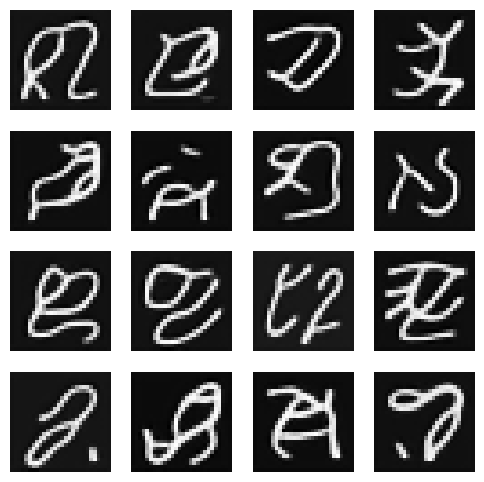

In [19]:
# Sampling : Reverse the process to generate images

@torch.no_grad()
def sample_images(n_samples=16):
  model.eval()
  x = torch.randn((n_samples, 1, 28, 28)).to(device)

  for t in reversed(range(1, timesteps, 10)): # Reverse diffusion in steps
    noise_pred = model(x, torch.full((n_samples, ), t, device=device).float().unsqueeze(-1).unsqueeze(-1))
    x = x - noise_pred

  return x.cpu()

# Generate samples
samples = sample_images().squeeze().numpy()

# plot results
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
  ax.imshow(samples[i], cmap="gray")
  ax.axis("off")

plt.show()



In [ ]:
# save the model

torch.save(model.state_dict(), "simple_unet.pth")